# Trabajo Práctico 1 - Visión por Computadora

### Alumnos:
* BETTIG, Santiago Federico
* DIEGUEZ, Manuel

#### Parte 1

1.a) Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación. \
1.b) Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

#### Parte 1 - Resolución

Lo primero que vamos a hacer es realizar una función para aplicar el algoritmo white-patch. Primero que nada, debemos sabemos en que se basa el algoritmo.

El algoritmo white-patch permite corregir la influencia de la luz sobre el objeto. El algoritmo asume que el valor máximo de cada canal es el color del blanco bajo la luz de la escena, por ende, lo primero que se hace es buscar ese valor máximo:

$$
R_{max}(img): Valor\,máximo\,del\,canal\,R\,de\,la\,imagen \\
G_{max}(img): Valor\,máximo\,del\,canal\,G\,de\,la\,imagen \\
B_{max}(img): Valor\,máximo\,del\,canal\,B\,de\,la\,imagen
$$

Luego debe tomarse ese valor y normalizar cada canal por el coeficiente que representa el valor de la luz blanca

$$
R'(Img) = \frac{255}{R_{max}(Img)}R \\
G'(Img) = \frac{255}{G_{max}(Img)}G \\
B'(Img) = \frac{255}{B_{max}(Img)}B
$$

Pasamos a la definición de la función:

In [2]:
# Importamos las bibliotecas que necesitamos para le resolución
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [3]:
# Aplica el algoritmo White Patch sobre la imagen que se pasa
# por parámetro
def white_patch(input_image:np.ndarray, percentil:float=100.0) -> np.ndarray:
    # Primero que nada, dividimos la imagen en los 3
    # canales
    b, g, r = cv.split(input_image)

    # Obtenemos el valor máximo de cada uno de ellos
    r_max = np.percentile(r, percentil)
    g_max = np.percentile(g, percentil)
    b_max = np.percentile(b, percentil)

    print(f"Percentil {percentil}%: R max: {r_max}, G max: {g_max}, B max: {b_max}")
    # Normalizamos cada uno de los canales
    r_new = 255/r_max * r
    g_new = 255/g_max * g
    b_new = 255/b_max * b
    
    r_clip = np.clip(r_new, a_min=0, a_max=255)
    g_clip = np.clip(g_new, a_min=0, a_max=255)
    b_clip = np.clip(b_new, a_min=0, a_max=255)

    # Volvermos a integrar los tres canales, nos aseguramos de que
    # cada canal quede como uint8
    img_white_patch = cv.merge((b_clip, g_clip, r_clip)).astype('uint8')

    return img_white_patch

def get_max(input_image:np.ndarray) -> tuple:
    # Primero que nada, dividimos la imagen en los 3
    # canales
    b, g, r = cv.split(input_image)

    # Obtenemos el valor máximo de cada uno de ellos
    r_max = np.max(r)
    g_max = np.max(g)
    b_max = np.max(b)

    return (r_max, g_max, b_max)

----------------------------------------------------------------------

Imagen: test_blue.png
Maximos de la imagen original: (np.uint8(165), np.uint8(138), np.uint8(200))
Percentil 100%: R max: 165.0, G max: 138.0, B max: 200.0


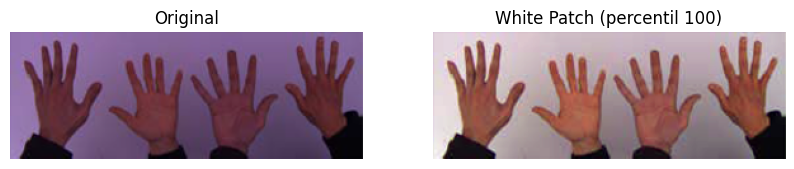

----------------------------------------------------------------------

Imagen: test_green.png
Maximos de la imagen original: (np.uint8(210), np.uint8(250), np.uint8(171))
Percentil 100%: R max: 210.0, G max: 250.0, B max: 171.0


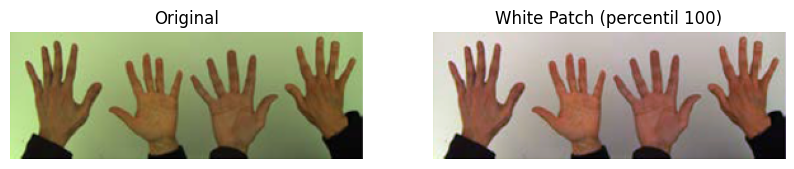

----------------------------------------------------------------------

Imagen: test_red.png
Maximos de la imagen original: (np.uint8(247), np.uint8(157), np.uint8(175))
Percentil 100%: R max: 247.0, G max: 157.0, B max: 175.0


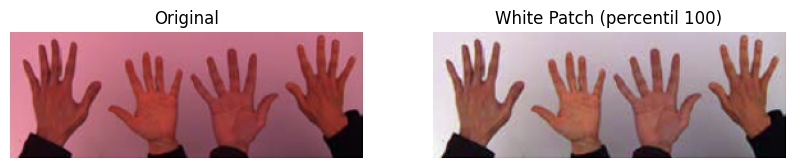

----------------------------------------------------------------------

Imagen: wp_blue.jpg
Maximos de la imagen original: (np.uint8(255), np.uint8(255), np.uint8(255))
⚠️ Hay al menos un canal saturado (llega a 255) -> comparamos percentil 100 vs 99
Percentil 100%: R max: 255.0, G max: 255.0, B max: 255.0
Percentil 99%: R max: 117.0, G max: 86.0, B max: 254.0


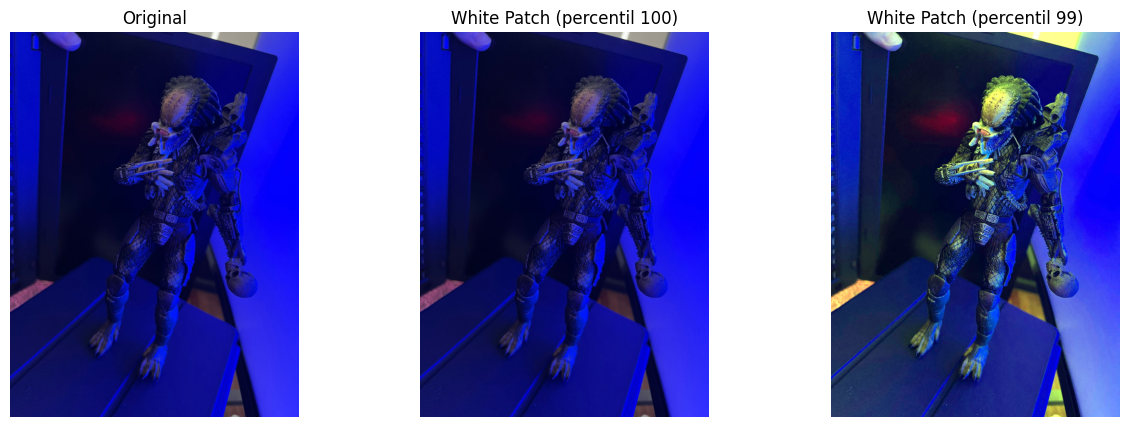

----------------------------------------------------------------------

Imagen: wp_green.png
Maximos de la imagen original: (np.uint8(126), np.uint8(252), np.uint8(155))
Percentil 100%: R max: 126.0, G max: 252.0, B max: 155.0


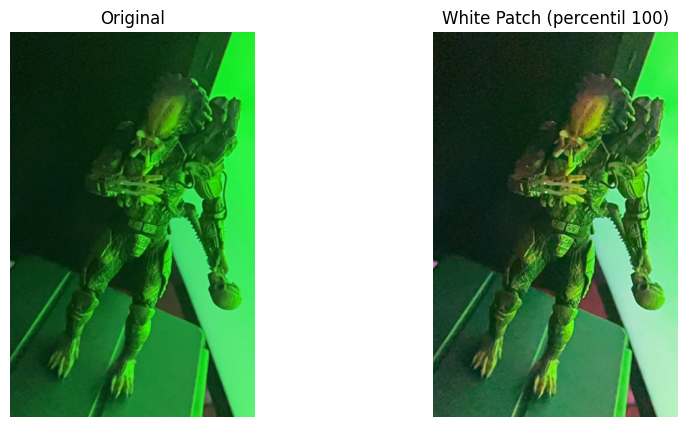

----------------------------------------------------------------------

Imagen: wp_green2.jpg
Maximos de la imagen original: (np.uint8(170), np.uint8(255), np.uint8(172))
⚠️ Hay al menos un canal saturado (llega a 255) -> comparamos percentil 100 vs 99
Percentil 100%: R max: 170.0, G max: 255.0, B max: 172.0
Percentil 99%: R max: 70.0, G max: 255.0, B max: 56.0


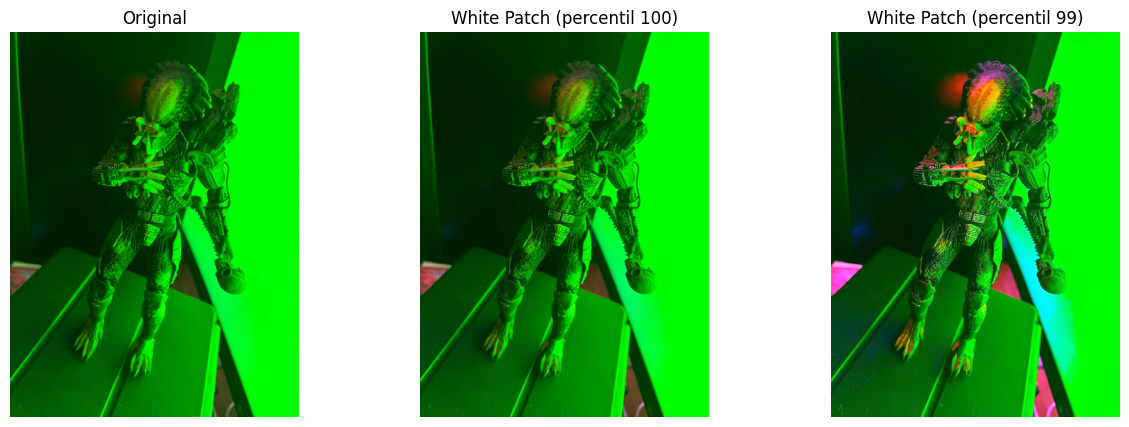

----------------------------------------------------------------------

Imagen: wp_red.png
Maximos de la imagen original: (np.uint8(255), np.uint8(134), np.uint8(122))
⚠️ Hay al menos un canal saturado (llega a 255) -> comparamos percentil 100 vs 99
Percentil 100%: R max: 255.0, G max: 134.0, B max: 122.0
Percentil 99%: R max: 255.0, G max: 74.0, B max: 102.0


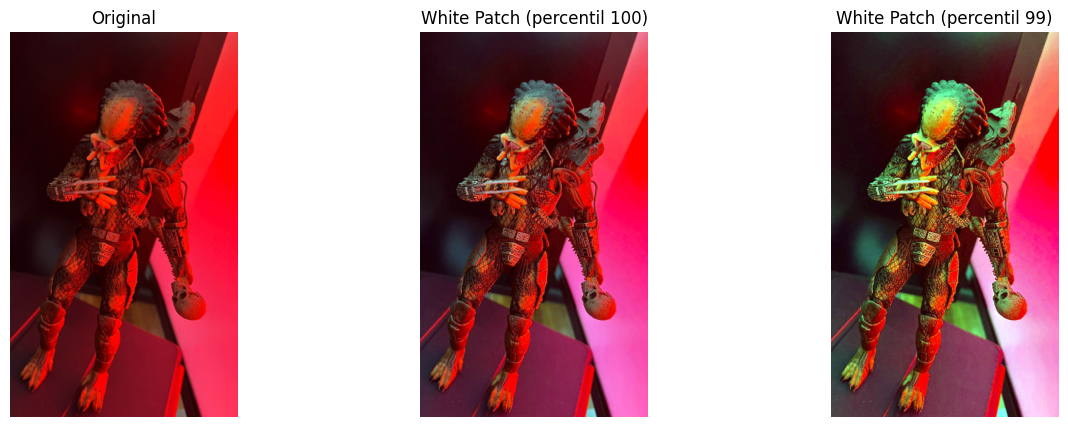

----------------------------------------------------------------------

Imagen: wp_red2.jpg
Maximos de la imagen original: (np.uint8(255), np.uint8(201), np.uint8(203))
⚠️ Hay al menos un canal saturado (llega a 255) -> comparamos percentil 100 vs 99
Percentil 100%: R max: 255.0, G max: 201.0, B max: 203.0
Percentil 99%: R max: 255.0, G max: 119.0, B max: 119.0


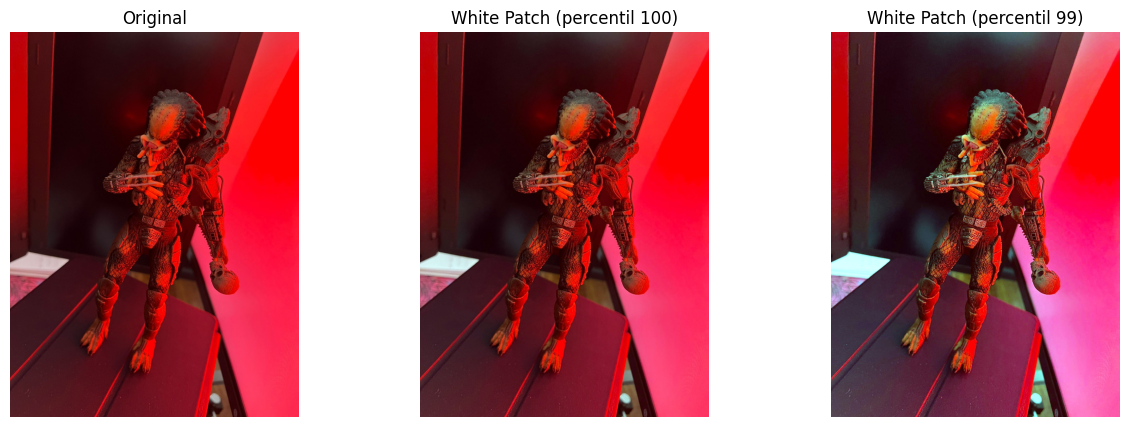

In [4]:
import os

carpeta = './img/white_patch/'

for nombre_archivo in os.listdir(carpeta):
    # Abrimos la imagen
    img_path = os.path.join(carpeta, nombre_archivo)
    img_i = cv.imread(img_path)

    if img_i is not None:
        # Obtenemos los máximos de cada canal, chequeamos si hay saturación (llega a 255)
        r_max, g_max, b_max = get_max(img_i)
        print("-"*70)
        print(f"\nImagen: {nombre_archivo}")
        print(f"Maximos de la imagen original: {(r_max, g_max, b_max)}")

        hay_saturacion = max(r_max, g_max, b_max) == 255

        if hay_saturacion:
            # Si hay saturación, aplicamos el algoritmo con percentil 100 y 99 para comparar resultados
            print("⚠️ Hay al menos un canal saturado (llega a 255) -> comparamos percentil 100 vs 99")

            img_wp_100 = white_patch(img_i, percentil=100)
            img_wp_99 = white_patch(img_i, percentil=99)

            plt.figure(figsize=(15, 5))

            plt.subplot(131)
            plt.imshow(cv.cvtColor(img_i, cv.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title('Original')

            plt.subplot(132)
            plt.imshow(cv.cvtColor(img_wp_100, cv.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title('White Patch (percentil 100)')

            plt.subplot(133)
            plt.imshow(cv.cvtColor(img_wp_99, cv.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title('White Patch (percentil 99)')

            plt.show()

        else:
            img_wp_100 = white_patch(img_i, percentil=100)

            plt.figure(figsize=(10, 5))

            plt.subplot(121)
            plt.imshow(cv.cvtColor(img_i, cv.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title('Original')

            plt.subplot(122)
            plt.imshow(cv.cvtColor(img_wp_100, cv.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title('White Patch (percentil 100)')

            plt.show()
    else:
        print("No se logró abrir la imagen :(")

#### Conclusiones sobre White Patch

Vemos que el algoritmo White-Patch funciona mejor con las imagenes que no tienen uno de sus canales saturados, ya que de esta forma la normalizacion del algoritmo mejora realmente el rango de valores de ese canal en la imagen. En las imagenes que tienen un canal saturado, la normalizacion del canal saturado devuelve el mismo valor. Como solución se puede utilizar algun percentil alto del 98% o 99% por ejemplo, pero esto va a hacer saturar los pixeles que queden por fuera de este percentil, siendo este otro problema

----

#### Parte 2

2.a) Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grises y visualizarlas. \
2.b) Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

#### Parte 2 - Resolución

Lo primero que debemos hacer es abrir las imágenes img1_tp.png y img2_tp.png en escala de grises y visualzarlas.

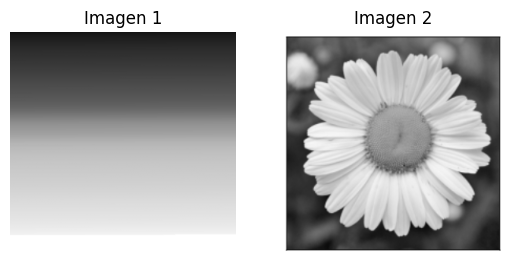

In [5]:
path_img1_tp = './img/img1_tp.png'
path_img2_tp = './img/img2_tp.png'

# Abrimos la imagen 1 en escala de grises
img1_tp = cv.imread(path_img1_tp, cv.IMREAD_GRAYSCALE)
if img1_tp is None:
    print("No se encontró la imagen 1")

# Abrimos la imagen 2 en escala de grises
img2_tp = cv.imread(path_img2_tp, cv.IMREAD_GRAYSCALE)
if img2_tp is None:
    print("No se encontró la imagen 2")

# Mostramos la imagen 1
plt.subplot(121)
plt.imshow(img1_tp, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.title('Imagen 1')

# Mostramos la imagen 2
plt.subplot(122)
plt.imshow(img2_tp, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.title('Imagen 2')

plt.show()

Luego, debemos elegir una cantidad de bins convenientes y graficar sus respectivos histogramas

Text(0, 0.5, 'Frecuencia')

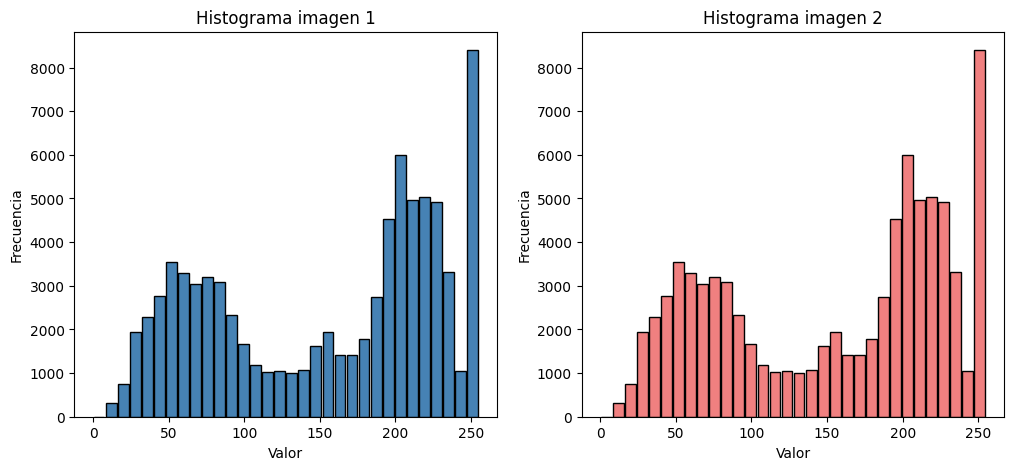

In [6]:
bins = 32
bins_edges = [0, 255]

hist1, bins1 = np.histogram(img1_tp.ravel(), bins, bins_edges)
hist2, bins2 = np.histogram(img2_tp.ravel(), bins, bins_edges)

# Centro de cada bin (para ubicar la barra) y ancho (para que no se solapen)
bin_centers1 = (bins1[:-1] + bins1[1:]) / 2
bin_centers2 = (bins2[:-1] + bins2[1:]) / 2
ancho = (bins1[1] - bins1[0]) * 0.9  # 0.9 para dejar un pequeño espacio entre barras

plt.figure(figsize=(12, 5))
# Mostramos la imagen 1
plt.subplot(121)
#plt.step(bins1[:-1], hist1, where='post')
plt.bar(bin_centers1, hist1, width=ancho, color='steelblue', edgecolor='black')
plt.title('Histograma imagen 1')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostramos la imagen 2
plt.subplot(122)
plt.bar(bin_centers2, hist2, width=ancho, color='lightcoral', edgecolor='black')
plt.title('Histograma imagen 2')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

#print(img1_tp.size, hist1.sum())

#### Observaciones

A simple vista vemos un gran problema en los histogramas: existe un pico en torno a los valores mas altos (Cercanos al 255). Esto se debe al predominio del blanco en ambas fotos. Esto podríamos consederarlo como un outlier, por lo que conviene eliminarlo. Una vez eliminado el outlier (solo para la visualización), veremos lo siguiente:


Los histogramas son iguales
----------------------------------------------------------------------


Text(0, 0.5, 'Frecuencia')

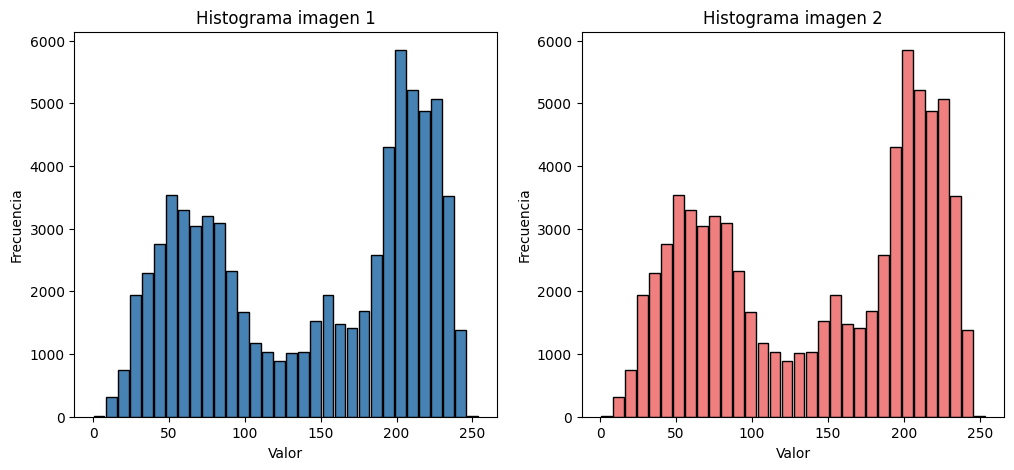

In [ ]:
bins = 32
bins_edges = [0, 254]

hist1, bins1 = np.histogram(img1_tp.ravel(), bins, bins_edges)
hist2, bins2 = np.histogram(img2_tp.ravel(), bins, bins_edges)

# Centro de cada bin (para ubicar la barra) y ancho (para que no se solapen)
bin_centers1 = (bins1[:-1] + bins1[1:]) / 2
bin_centers2 = (bins2[:-1] + bins2[1:]) / 2
ancho = (bins1[1] - bins1[0]) * 0.9  # 0.9 para dejar un pequeño espacio entre barras

if ((hist1==hist2).all()):
    print("Los histogramas son iguales")
else:
    print("Los histogramas son distintos")
print("-"*70)

plt.figure(figsize=(12, 5))
# Mostramos la imagen 1
plt.subplot(121)
plt.bar(bin_centers1, hist1, width=ancho, color='steelblue', edgecolor='black')
plt.title('Histograma imagen 1')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostramos la imagen 2
plt.subplot(122)
plt.bar(bin_centers2, hist2, width=ancho, color='lightcoral', edgecolor='black')
plt.title('Histograma imagen 2')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')


#### Conclusiones

Está mas que claro que el contenido de las fotos distan entre si, por lo que podemos decir que deberían ser claramente diferenciables. El problema es que si vemos el histograma no podremos distinguirlas. En las imágenes anteriores se observa ambos histogramas, correspondientes a las imágenes img1_tp y img2_tp. Comparando ambos histogramas, sabemos que son exactamente iguales, por lo que no será posible distinguir una u otra imagen a partir de los mismos.

En pocas palabras, **no tendrá sentido utilizar el histograma como feature para el entrenamiento de un modelo de detección/clasificación.**